In [1]:
import httpx
import asyncio
import time
import matplotlib.pyplot as plt


In [4]:
#Aim:To fire 10 http requests to httpbin and to determine latency
async def fire_req(client, url):
    start = time.time()
    response = await client.post(url, json={"test": "payload"})
    latency = round((time.time() - start) * 1000, 2)
    return latency

async def run_concurrent(n=10):
    url = "https://jsonplaceholder.typicode.com/posts"
    async with httpx.AsyncClient() as client: #AsyncClient is the async version of httpx 
        tasks = [fire_req(client, url) for _ in range(n)]
        latencies = await asyncio.gather(*tasks)
    return latencies

latencies = await run_concurrent(10)
print(f"Latencies (ms): {latencies}")
print(f"Average: {round(sum(latencies)/len(latencies), 2)}ms")


Latencies (ms): [689.76, 276.99, 283.31, 723.31, 282.12, 677.05, 278.65, 275.5, 290.8, 697.29]
Average: 447.48ms


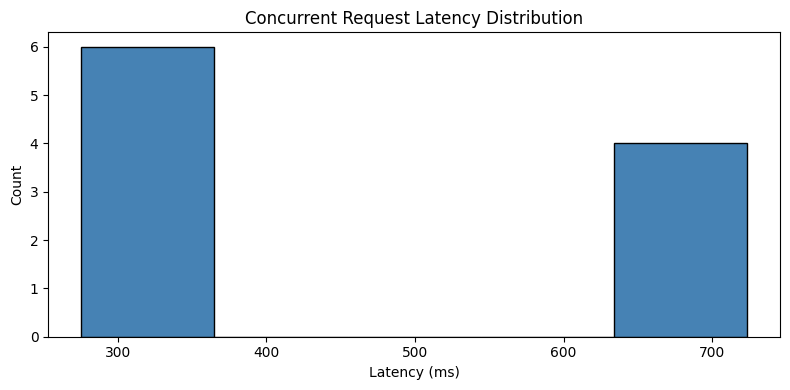

In [5]:
plt.figure(figsize=(8,4))
plt.hist(latencies, bins=5, color="steelblue", edgecolor="black")
plt.title("Concurrent Request Latency Distribution")
plt.xlabel("Latency (ms)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()